# Text-Only Fashion Style Classification (FashionBERT)

## Objective
This notebook ports the **text-only robustness** experiment from the fusion project’s `TextOnly_Robustness_Experiments` template into the **StyleFusion** layout (same spirit as `6_Image_only.ipynb`). We fine-tune a **frozen BERT-base-uncased** encoder with an MLP head (768 → 256 → 128 → 14) on **FashionStyle14**, using **10** stratified splits from `seeds_list.txt` (the file may list more seeds; we only run the first **10**).

## Pipeline (end-to-end)
1. **Resolve paths** from the repo root or `StyleFusion/`, load seeds from `seeds_list.txt`, keep **`NUM_SEEDS_TO_USE = 10`**, set hyperparameters.
2. Check device (CPU / CUDA), VRAM, and pick a safe batch size (AMP on CUDA when available).
3. Load paths from `complete_dataset.csv`, merge **captions** from the caption CSV (see Inputs), keep rows with files on disk and non-empty text.
4. For **each seed**: stratified 70% / 15% / 15% train/val/test (`random_state=seed`), build DataLoaders, initialize the model (**model-init seed fixed at 42**), train with early stopping on **validation macro-F1**, evaluate on test, save artifacts under `results/text_only/fashionbert/seed_<seed>/`.
5. Aggregate test metrics into `all_seeds_summary.csv` and print mean ± std.
6. **Learning curves** are **displayed in the notebook** (`plt.show()`); we do **not** write PNGs (unlike the older fusion notebook’s `plt.savefig`).

## Inputs
| Input | Description |
|-------|-------------|
| `FashionStyle14_v1/complete_dataset.csv` | One relative image path per line (`dataset/<style>/...`). |
| `FashionStyle14_v1/seeds_list.txt` | Robustness seeds (`Seed N` lines); **first 10** parsed values are used. |
| `FashionStyle14_v1/fashion_captions_llava_success.csv` | Captions keyed by relative paths (set `CAPTION_CSV` in §1 if your file name differs). If a `status` column exists, only `success` rows are kept. |
| Pre-trained weights | `bert-base-uncased` (Hugging Face Transformers). |

## Outputs (on disk)
Per seed: **`results/text_only/fashionbert/seed_<seed>/`**

| File | Description |
|------|-------------|
| `best_model.pt` | Best validation macro-F1 checkpoint (head weights). |
| `training_history.json` | Per-epoch train/val loss and metrics. |
| `test_metrics.json` | Overall test accuracy, macro precision / recall / F1. |
| `per_class.csv` | Per-class acc / precision / recall / F1. |

Aggregated: **`results/text_only/fashionbert/all_seeds_summary.csv`** (one row per seed).

**Figures:** learning curves are **in-notebook only** (no image files saved).

## Notes
- Code and comments are **English** only.
- Working directory may be the **repo root** or **`StyleFusion/`**; path resolution matches the image-only notebook pattern.

## 1. Configuration, imports, and paths

In [1]:
from __future__ import annotations

import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Any, Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore", category=UserWarning)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

LEARNING_RATE = 5e-5
BATCH_SIZE = 32
MAX_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.5
WEIGHT_DECAY = 1e-4
MODEL_INIT_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MAX_SEQ_LENGTH = 128

BERT_MODEL_ID = "bert-base-uncased"
NUM_SEEDS_TO_USE = 10

random.seed(MODEL_INIT_SEED)
np.random.seed(MODEL_INIT_SEED)
torch.manual_seed(MODEL_INIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def load_seeds(seeds_file: Path) -> List[int]:
    """Parse all seeds from `seeds_list.txt` (same pattern as image-only notebook)."""
    if not seeds_file.is_file():
        raise FileNotFoundError(f"Missing seeds file: {seeds_file}")
    content = seeds_file.read_text(encoding="utf-8")
    matches = re.findall(r"Seed\s+(\d+)", content, flags=re.IGNORECASE)
    seeds = sorted({int(s) for s in matches if 1 <= int(s) <= 500})
    if len(seeds) != 30:
        print(f"Warning: expected 30 seeds in file, found {len(seeds)}")
    return seeds


def resolve_paths() -> Tuple[Path, Path, Path]:
    """Find project root and FashionStyle14_v1 (same idea as `6_Image_only.ipynb`)."""
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd / "StyleFusion",
        cwd.parent / "StyleFusion",
        cwd / "FusionStyle",
        cwd.parent / "FusionStyle",
    ]
    for root in candidates:
        data_dir = root / "FashionStyle14_v1"
        dataset_dir = data_dir / "dataset"
        has_splits = (data_dir / "train.csv").is_file() or (data_dir / "train_new.csv").is_file()
        if has_splits and dataset_dir.is_dir():
            results_root = root / "results" / "text_only"
            return root, data_dir, results_root
    raise FileNotFoundError(
        "Could not locate FashionStyle14_v1 with train (or train_new) CSV and dataset/. "
        "Open the notebook from the repo root or StyleFusion/."
    )


PROJECT_ROOT, DATA_DIR, RESULTS_ROOT = resolve_paths()
IMAGE_ROOT = DATA_DIR
SEEDS_FILE = DATA_DIR / "seeds_list.txt"
COMPLETE_CSV = DATA_DIR / "complete_dataset.csv"
CAPTION_CSV = DATA_DIR / "caption" / "fashion_captions_llava_success.csv"

for label, path, must_exist in [
    ("DATA_DIR", DATA_DIR, "dir"),
    ("FashionStyle14_v1/dataset/", DATA_DIR / "dataset", "dir"),
    ("SEEDS_FILE", SEEDS_FILE, "file"),
    ("COMPLETE_CSV", COMPLETE_CSV, "file"),
    ("CAPTION_CSV", CAPTION_CSV, "file"),
]:
    ok = path.is_dir() if must_exist == "dir" else path.is_file()
    if not ok:
        raise FileNotFoundError(f"Missing {label}: {path}")

ALL_PARSED_SEEDS = load_seeds(SEEDS_FILE)
SEEDS = ALL_PARSED_SEEDS[:NUM_SEEDS_TO_USE]
if len(SEEDS) < NUM_SEEDS_TO_USE:
    print(f"Warning: only {len(SEEDS)} seeds available; expected {NUM_SEEDS_TO_USE}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("COMPLETE_CSV:", COMPLETE_CSV)
print("CAPTION_CSV:", CAPTION_CSV)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"Using {len(SEEDS)} seeds:", SEEDS)

c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle
DATA_DIR: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\FashionStyle14_v1
COMPLETE_CSV: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\FashionStyle14_v1\complete_dataset.csv
CAPTION_CSV: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\FashionStyle14_v1\caption\fashion_captions_llava_success.csv
RESULTS_ROOT: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\text_only
Using 10 seeds: [13, 14, 16, 17, 45, 48, 53, 58, 72, 102]


## 2. Hardware check and runtime settings

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    total_mem_gb = props.total_memory / (1024**3)
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {total_mem_gb:.2f} GB")
    if total_mem_gb < 8:
        BATCH_SIZE = 8
    elif total_mem_gb < 12:
        BATCH_SIZE = 16
    else:
        BATCH_SIZE = 32
else:
    print("CUDA not available; using CPU (training will be slow).")
    BATCH_SIZE = 8

print(f"Selected BATCH_SIZE: {BATCH_SIZE}")
print(f"Using AMP on CUDA: {use_amp}")

CUDA device: NVIDIA GeForce RTX 3060 Ti
Total GPU memory: 8.00 GB
Selected BATCH_SIZE: 8
Using AMP on CUDA: True


## 3. Load dataset, captions, and stratified split helper

In [3]:
def normalize_rel_path(path_str: str) -> str:
    return str(path_str).strip().replace("\\", "/")


def canonical_merge_key(raw: str) -> str:
    """Normalize paths so caption CSV rows join to `complete_dataset` (`dataset/<style>/...`)."""
    s = normalize_rel_path(raw).lstrip("./")
    low = s.lower()

    prefixes = ("fashionstyle14_v1/",)
    changed = True
    while changed:
        changed = False
        for pref in prefixes:
            if low.startswith(pref):
                s = s[len(pref) :].lstrip("/")
                low = s.lower()
                changed = True
                break

    marker = "dataset/"
    ix = low.find(marker)
    if ix >= 0:
        return normalize_rel_path(s[ix:])

    p = Path(s)
    if p.is_absolute():
        root = IMAGE_ROOT.resolve()
        try:
            rel = Path(p.resolve()).relative_to(root)
            return normalize_rel_path(str(rel).replace(os.sep, "/"))
        except ValueError:
            pass

    return s


def load_complete_dataset(csv_path: Path) -> pd.DataFrame:
    lines = csv_path.read_text(encoding="utf-8").splitlines()
    rel = [ln.strip() for ln in lines if ln.strip()]
    df = pd.DataFrame({"rel_path": rel})
    df["rel_path"] = df["rel_path"].map(normalize_rel_path)
    df["merge_key"] = df["rel_path"].map(canonical_merge_key)
    df["style"] = df["merge_key"].str.split("/").str[1]
    df["abs_path"] = df["rel_path"].apply(lambda r: str((IMAGE_ROOT / r.replace("/", os.sep)).resolve()))
    df = df[df["abs_path"].map(os.path.isfile)].reset_index(drop=True)
    return df


def load_captions_long(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")
    work = df.copy()
    if "status" in work.columns:
        work = work[work["status"].astype(str).str.lower() == "success"]
    path_col = None
    path_aliases = {"image_path", "rel_path", "path", "filename", "file_path", "filepath", "image"}
    for c in work.columns:
        if c.lower().strip() in path_aliases:
            path_col = c
            break
    if path_col is None:
        raise ValueError(f"Caption CSV needs an image path column; got columns {list(work.columns)}")
    cap_col = None
    text_aliases = {"caption", "text", "description"}
    for c in work.columns:
        if c.lower().strip() in text_aliases:
            cap_col = c
            break
    if cap_col is None:
        caption_named = [c for c in work.columns if "caption" in str(c).lower()]
        cap_col = caption_named[0] if caption_named else None
    if cap_col is None:
        raise ValueError(f"Caption CSV needs a caption column; got columns {list(work.columns)}")
    out = work[[path_col, cap_col]].rename(columns={path_col: "raw_image_path", cap_col: "caption"})
    out["merge_key"] = out["raw_image_path"].map(canonical_merge_key)
    out["caption"] = out["caption"].fillna("").astype(str).str.strip()
    out = out[out["caption"] != ""].drop_duplicates(subset=["merge_key"], keep="last")
    return out[["merge_key", "caption"]].reset_index(drop=True)


df_paths = load_complete_dataset(COMPLETE_CSV)
cap_df = load_captions_long(CAPTION_CSV)
df_full = df_paths.merge(cap_df[["merge_key", "caption"]], on="merge_key", how="inner").reset_index(drop=True)

if len(df_full) == 0:
    sample_p = df_paths["merge_key"].head(5).tolist()
    sample_c = cap_df["merge_key"].head(5).tolist()
    inter = len(set(df_paths["merge_key"]) & set(cap_df["merge_key"]))
    print("DEBUG dataset merge_keys:", sample_p)
    print("DEBUG caption merge_keys:", sample_c)
    print("DEBUG |paths|", len(df_paths), "|captions|", len(cap_df), "|intersection|", inter)
    raise ValueError(
        "No rows after joining images and captions. Check path formats in caption CSV vs complete_dataset.csv "
        "(see canonical_merge_key)."
    )

classes = sorted(df_full["style"].unique().tolist())
assert len(classes) == 14, f"Expected 14 classes, got {len(classes)}: {classes}"
style_to_idx = {s: i for i, s in enumerate(classes)}
num_classes = len(classes)

print("Samples with captions (files on disk):", len(df_full))
print("Number of classes:", num_classes)
print("Classes:", classes)
print(f"Data splits will be created per seed ({len(SEEDS)} experiments).")


def split_by_seed(df: pd.DataFrame, seed_value: int) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=(VAL_RATIO + TEST_RATIO),
        stratify=df["style"],
        random_state=seed_value,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=temp_df["style"],
        random_state=seed_value,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

Samples with captions (files on disk): 13212
Number of classes: 14
Classes: ['conservative', 'dressy', 'ethnic', 'fairy', 'feminine', 'gal', 'girlish', 'kireime-casual', 'lolita', 'mode', 'natural', 'retro', 'rock', 'street']
Data splits will be created per seed (10 experiments).


## 4. PyTorch dataset and DataLoaders

In [4]:
class FashionTextDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, style_to_idx: Dict[str, int]):
        self.frame = frame.reset_index(drop=True)
        self.style_to_idx = style_to_idx

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.frame.iloc[idx]
        return {"caption": str(row["caption"]), "label": self.style_to_idx[row["style"]]}


NUM_WORKERS = 0


def make_loaders(
    train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    train_ds = FashionTextDataset(train_df, style_to_idx)
    val_ds = FashionTextDataset(val_df, style_to_idx)
    test_ds = FashionTextDataset(test_df, style_to_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


print("Dataset class ready. Batch size:", BATCH_SIZE)

Dataset class ready. Batch size: 8


## 5. Model: frozen BERT + MLP head

In [5]:
class TextOnlyFashionClassifier(nn.Module):
    """Frozen BERT [CLS] features (768) + head 768→256→128→num_classes (robustness reference)."""

    def __init__(self, bert: nn.Module, tokenizer: AutoTokenizer, num_classes: int, dropout: float = DROPOUT):
        super().__init__()
        self.bert = bert
        self.tokenizer = tokenizer
        for p in self.bert.parameters():
            p.requires_grad = False
        self.bert.eval()
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, captions: List[str]) -> torch.Tensor:
        device = next(self.head.parameters()).device
        with torch.no_grad():
            enc = self.tokenizer(
                captions,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=MAX_SEQ_LENGTH,
            ).to(device)
            out = self.bert(**enc)
            cls = out.last_hidden_state[:, 0, :].float()
        return self.head(cls)


# Backbone + tokenizer are constructed fresh inside build_model() each seed (clean submodule graph).


def build_model() -> TextOnlyFashionClassifier:
    bert = AutoModel.from_pretrained(BERT_MODEL_ID)
    tok = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
    return TextOnlyFashionClassifier(bert, tok, num_classes=num_classes)


print("Model class ready; call build_model() each seed (fresh BERT submodule graph).")

Model class ready; call build_model() each seed (fresh BERT submodule graph).


## 6. Training, evaluation, and in-notebook learning curves

In [6]:
def evaluate(
    model: nn.Module, loader: DataLoader, criterion, device: torch.device, use_amp: bool
) -> Tuple[float, Dict[str, float], np.ndarray, np.ndarray]:
    model.eval()
    total_loss = 0.0
    all_preds: List[int] = []
    all_labels: List[int] = []
    n = len(loader.dataset)
    with torch.no_grad():
        for batch in loader:
            caps = batch["caption"]
            y = batch["label"].to(device, non_blocking=True)
            with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
                logits = model(caps)
                loss = criterion(logits, y)
            total_loss += float(loss.item()) * y.size(0)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())
    avg_loss = total_loss / max(n, 1)
    acc = accuracy_score(all_labels, all_preds)
    macro_p = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_r = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    metrics = {"loss": avg_loss, "accuracy": acc, "macro_precision": macro_p, "macro_recall": macro_r, "macro_f1": macro_f1}
    return avg_loss, metrics, np.array(all_preds), np.array(all_labels)


def train_one_epoch(model, loader, optimizer, criterion, device, use_amp) -> Tuple[float, float]:
    model.train()
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and device.type == "cuda")
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in loader:
        caps = batch["caption"]
        y = batch["label"].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp and device.type == "cuda"):
            logits = model(caps)
            loss = criterion(logits, y)
        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        total_loss += float(loss.item()) * y.size(0)
        preds = logits.argmax(dim=1)
        correct += int((preds == y).sum().item())
        total += int(y.size(0))
    return total_loss / max(total, 1), correct / max(total, 1)


def plot_learning_curves(history: Dict[str, Any], title: str) -> None:
    """Display learning curves in the notebook only (no PNG written; contrasts old fusion notebook savefig)."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_macro_f1"], label="val macro F1")
    axes[1].plot(epochs, history["train_acc"], label="train acc", alpha=0.7)
    axes[1].plot(epochs, history["val_acc"], label="val acc", alpha=0.7)
    axes[1].set_title("Metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def set_model_init_seed() -> None:
    random.seed(MODEL_INIT_SEED)
    np.random.seed(MODEL_INIT_SEED)
    torch.manual_seed(MODEL_INIT_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(MODEL_INIT_SEED)


def train_text_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    train_df: pd.DataFrame,
    out_dir: Path,
    model_name: str,
    seed_value: int,
    device: torch.device,
    use_amp: bool,
    plot_curves: bool = True,
) -> Dict[str, Any]:
    out_dir.mkdir(parents=True, exist_ok=True)

    y_train = train_df["style"].map(style_to_idx).values
    class_weights = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
    cw = torch.FloatTensor(class_weights).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "train_acc": [], "val_acc": []}
    best_f1 = -1.0
    best_state = None
    patience_left = EARLY_STOPPING_PATIENCE

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, use_amp)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion, device, use_amp)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_metrics["accuracy"])

        print(
            f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_metrics['accuracy']:.4f} macroF1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), out_dir / "best_model.pt")
    with open(out_dir / "training_history.json", "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)

    _, test_metrics, test_preds, test_labels = evaluate(model, test_loader, criterion, device, use_amp)

    per_class_precision = precision_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_recall = recall_score(test_labels, test_preds, average=None, zero_division=0)
    per_class_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)

    per_class_rows = []
    for i, cls in enumerate(classes):
        per_class_rows.append(
            {
                "class": cls,
                "acc": float(per_class_recall[i]),
                "precision": float(per_class_precision[i]),
                "recall": float(per_class_recall[i]),
                "f1": float(per_class_f1[i]),
            }
        )
    per_class_df = pd.DataFrame(per_class_rows, columns=["class", "acc", "precision", "recall", "f1"])

    with open(out_dir / "test_metrics.json", "w", encoding="utf-8") as f:
        json.dump({k: float(v) for k, v in test_metrics.items()}, f, indent=2)
    per_class_csv_path = out_dir / "per_class.csv"
    per_class_df.to_csv(per_class_csv_path, index=False, encoding="utf-8")

    print(f"\n[{model_name} | seed {seed_value}] Test metrics:", test_metrics)
    print(f"[{model_name} | seed {seed_value}] Per-class metrics ({per_class_csv_path}):")
    print(per_class_df.to_string(index=False))

    if plot_curves:
        plot_learning_curves(history, title=f"Learning curves — {model_name} (seed {seed_value})")

    return {
        "seed": seed_value,
        "history": history,
        "test_metrics": test_metrics,
        "per_class_csv": str(per_class_csv_path),
        "out_dir": str(out_dir),
    }


def run_robustness_text(model_name: str, build_model_fn: Callable[[], nn.Module]) -> pd.DataFrame:
    model_root = RESULTS_ROOT / model_name
    model_root.mkdir(parents=True, exist_ok=True)
    rows: List[Dict[str, Any]] = []

    for seed_idx, seed_value in enumerate(SEEDS, start=1):
        seed_dir = model_root / f"seed_{seed_value}"
        done_marker = seed_dir / "test_metrics.json"
        if done_marker.is_file():
            print(f"[{model_name}] Seed {seed_value} ({seed_idx}/{len(SEEDS)}): skip (already done)")
            with open(done_marker, encoding="utf-8") as f:
                cached = json.load(f)
            rows.append({"seed": seed_value, **cached})
            continue

        print("=" * 70)
        print(f"[{model_name}] Experiment {seed_idx}/{len(SEEDS)} | data split seed = {seed_value}")
        print("=" * 70)

        train_df, val_df, test_df = split_by_seed(df_full, seed_value)
        print(f"  Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

        train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df)

        set_model_init_seed()
        model = build_model_fn().to(device)

        result = train_text_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            train_df,
            out_dir=seed_dir,
            model_name=model_name,
            seed_value=seed_value,
            device=device,
            use_amp=use_amp,
            plot_curves=True,
        )
        rows.append({"seed": seed_value, **{k: float(v) for k, v in result["test_metrics"].items()}})

        del model, train_loader, val_loader, test_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(rows)
    summary_path = model_root / "all_seeds_summary.csv"
    summary_df.to_csv(summary_path, index=False, encoding="utf-8")
    print(f"\n[{model_name}] Saved summary: {summary_path}")
    if len(summary_df) > 0:
        print(
            f"[{model_name}] macro_f1 mean +/- std: "
            f"{summary_df['macro_f1'].mean():.4f} +/- {summary_df['macro_f1'].std():.4f}"
        )
    return summary_df


print("Training utilities ready.")

Training utilities ready.


## 7. FashionBERT: text-only robustness (10 seeds)

[fashionbert] Experiment 1/10 | data split seed = 13
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6354 acc 0.0854 | val loss 2.6157 acc 0.1569 macroF1 0.1004
Epoch 02 | train loss 2.5975 acc 0.1268 | val loss 2.5262 acc 0.2275 macroF1 0.1663
Epoch 03 | train loss 2.5136 acc 0.1657 | val loss 2.3818 acc 0.2275 macroF1 0.1448
Epoch 04 | train loss 2.4043 acc 0.1919 | val loss 2.2633 acc 0.2639 macroF1 0.1973
Epoch 05 | train loss 2.3266 acc 0.2107 | val loss 2.1822 acc 0.2664 macroF1 0.2043
Epoch 06 | train loss 2.2770 acc 0.2290 | val loss 2.1402 acc 0.2785 macroF1 0.2235
Epoch 07 | train loss 2.2446 acc 0.2336 | val loss 2.1033 acc 0.2896 macroF1 0.2332
Epoch 08 | train loss 2.2121 acc 0.2442 | val loss 2.0767 acc 0.2997 macroF1 0.2486
Epoch 09 | train loss 2.1789 acc 0.2570 | val loss 2.0492 acc 0.3007 macroF1 0.2556
Epoch 10 | train loss 2.1685 acc 0.2605 | val loss 2.0467 acc 0.3037 macroF1 0.2552
Epoch 11 | train loss 2.1542 acc 0.2639 | val loss 2.0141 acc 0.3214 macroF1 0.2761
Epoch 12 | train loss 2.1367 acc 0.2674 | val loss 2.0042 acc 0.3199 macroF1

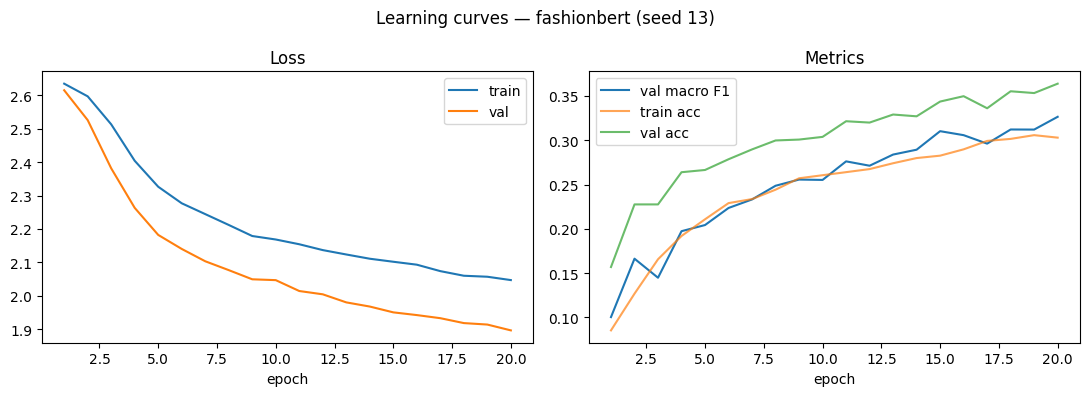

[fashionbert] Experiment 2/10 | data split seed = 14
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6348 acc 0.0852 | val loss 2.6124 acc 0.1357 macroF1 0.0468
Epoch 02 | train loss 2.5937 acc 0.1272 | val loss 2.5238 acc 0.2164 macroF1 0.1410
Epoch 03 | train loss 2.5090 acc 0.1683 | val loss 2.3770 acc 0.2230 macroF1 0.1495
Epoch 04 | train loss 2.4033 acc 0.1953 | val loss 2.2502 acc 0.2603 macroF1 0.1942
Epoch 05 | train loss 2.3202 acc 0.2144 | val loss 2.1643 acc 0.2841 macroF1 0.2164
Epoch 06 | train loss 2.2724 acc 0.2277 | val loss 2.1181 acc 0.2957 macroF1 0.2372
Epoch 07 | train loss 2.2351 acc 0.2381 | val loss 2.0844 acc 0.2972 macroF1 0.2368
Epoch 08 | train loss 2.2078 acc 0.2485 | val loss 2.0548 acc 0.3153 macroF1 0.2594
Epoch 09 | train loss 2.1807 acc 0.2540 | val loss 2.0363 acc 0.3068 macroF1 0.2478
Epoch 10 | train loss 2.1673 acc 0.2566 | val loss 2.0088 acc 0.3285 macroF1 0.2816
Epoch 11 | train loss 2.1460 acc 0.2644 | val loss 1.9934 acc 0.3370 macroF1 0.2965
Epoch 12 | train loss 2.1240 acc 0.2790 | val loss 1.9854 acc 0.3365 macroF1

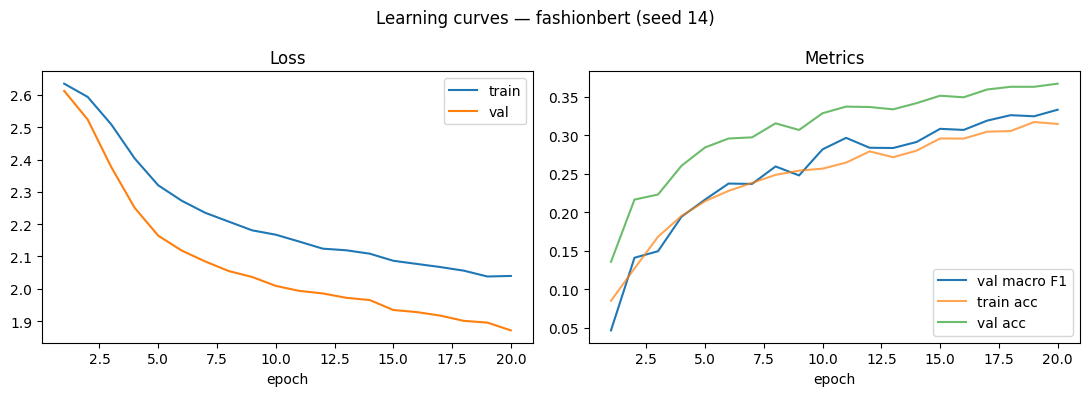

[fashionbert] Experiment 3/10 | data split seed = 16
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6337 acc 0.0813 | val loss 2.6125 acc 0.1176 macroF1 0.0626
Epoch 02 | train loss 2.5960 acc 0.1299 | val loss 2.5278 acc 0.2089 macroF1 0.1357
Epoch 03 | train loss 2.5033 acc 0.1650 | val loss 2.3949 acc 0.2225 macroF1 0.1489
Epoch 04 | train loss 2.3972 acc 0.1941 | val loss 2.2822 acc 0.2467 macroF1 0.1788
Epoch 05 | train loss 2.3220 acc 0.2136 | val loss 2.2012 acc 0.2810 macroF1 0.2372
Epoch 06 | train loss 2.2817 acc 0.2193 | val loss 2.1460 acc 0.2911 macroF1 0.2384
Epoch 07 | train loss 2.2299 acc 0.2385 | val loss 2.1172 acc 0.2896 macroF1 0.2395
Epoch 08 | train loss 2.2109 acc 0.2470 | val loss 2.0937 acc 0.3002 macroF1 0.2611
Epoch 09 | train loss 2.1800 acc 0.2572 | val loss 2.0633 acc 0.3153 macroF1 0.2663
Epoch 10 | train loss 2.1658 acc 0.2648 | val loss 2.0475 acc 0.3153 macroF1 0.2760
Epoch 11 | train loss 2.1496 acc 0.2664 | val loss 2.0342 acc 0.3204 macroF1 0.2701
Epoch 12 | train loss 2.1190 acc 0.2805 | val loss 2.0140 acc 0.3350 macroF1

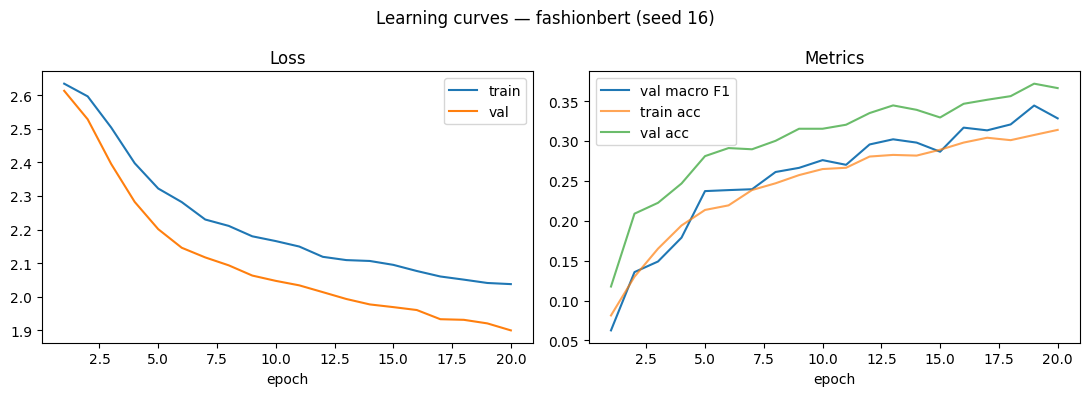

[fashionbert] Experiment 4/10 | data split seed = 17
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6354 acc 0.0876 | val loss 2.6119 acc 0.1604 macroF1 0.0777
Epoch 02 | train loss 2.5940 acc 0.1303 | val loss 2.5256 acc 0.2245 macroF1 0.1524
Epoch 03 | train loss 2.5014 acc 0.1711 | val loss 2.3836 acc 0.2210 macroF1 0.1576
Epoch 04 | train loss 2.3975 acc 0.1906 | val loss 2.2564 acc 0.2619 macroF1 0.2001
Epoch 05 | train loss 2.3215 acc 0.2102 | val loss 2.1905 acc 0.2573 macroF1 0.2003
Epoch 06 | train loss 2.2638 acc 0.2198 | val loss 2.1286 acc 0.2896 macroF1 0.2362
Epoch 07 | train loss 2.2238 acc 0.2365 | val loss 2.1135 acc 0.2876 macroF1 0.2377
Epoch 08 | train loss 2.2060 acc 0.2423 | val loss 2.0689 acc 0.3128 macroF1 0.2746
Epoch 09 | train loss 2.1779 acc 0.2567 | val loss 2.0501 acc 0.3219 macroF1 0.2797
Epoch 10 | train loss 2.1695 acc 0.2565 | val loss 2.0269 acc 0.3264 macroF1 0.2860
Epoch 11 | train loss 2.1432 acc 0.2645 | val loss 2.0132 acc 0.3355 macroF1 0.2925
Epoch 12 | train loss 2.1327 acc 0.2730 | val loss 1.9995 acc 0.3456 macroF1

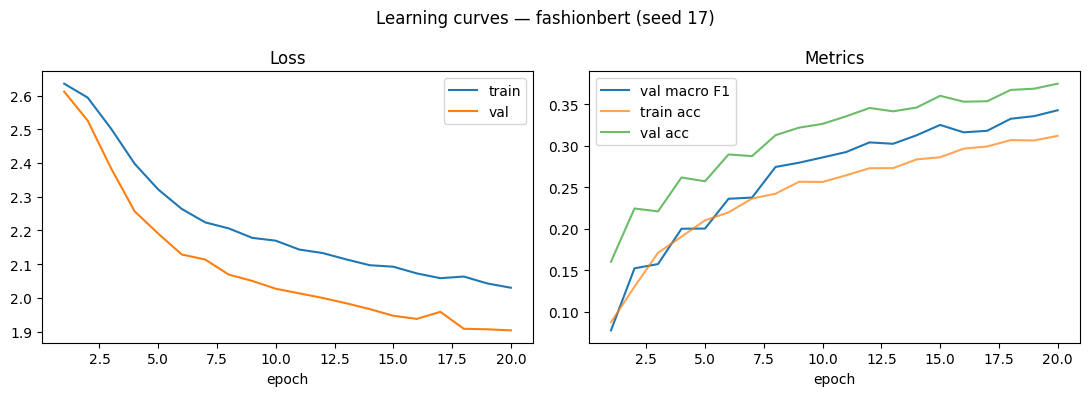

[fashionbert] Experiment 5/10 | data split seed = 45
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6350 acc 0.0827 | val loss 2.6129 acc 0.1054 macroF1 0.0679
Epoch 02 | train loss 2.5987 acc 0.1209 | val loss 2.5304 acc 0.2109 macroF1 0.1312
Epoch 03 | train loss 2.5096 acc 0.1714 | val loss 2.3866 acc 0.2311 macroF1 0.1728
Epoch 04 | train loss 2.4079 acc 0.1915 | val loss 2.2675 acc 0.2392 macroF1 0.1712
Epoch 05 | train loss 2.3246 acc 0.2143 | val loss 2.1737 acc 0.2846 macroF1 0.2295
Epoch 06 | train loss 2.2713 acc 0.2236 | val loss 2.1261 acc 0.2735 macroF1 0.2193
Epoch 07 | train loss 2.2330 acc 0.2389 | val loss 2.1053 acc 0.2866 macroF1 0.2273
Epoch 08 | train loss 2.2069 acc 0.2486 | val loss 2.0663 acc 0.3037 macroF1 0.2542
Epoch 09 | train loss 2.1943 acc 0.2511 | val loss 2.0483 acc 0.3123 macroF1 0.2548
Epoch 10 | train loss 2.1702 acc 0.2582 | val loss 2.0216 acc 0.3320 macroF1 0.2904
Epoch 11 | train loss 2.1522 acc 0.2698 | val loss 2.0049 acc 0.3285 macroF1 0.2797
Epoch 12 | train loss 2.1305 acc 0.2731 | val loss 1.9819 acc 0.3380 macroF1

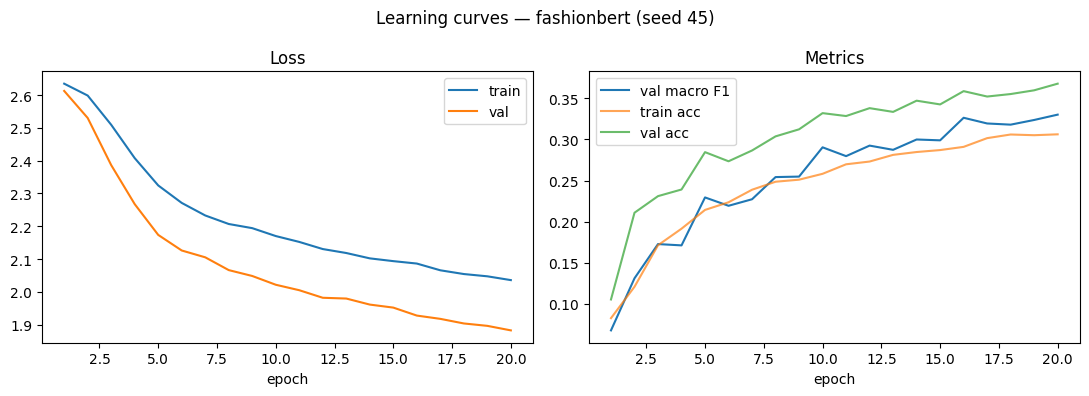

[fashionbert] Experiment 6/10 | data split seed = 48
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6358 acc 0.0781 | val loss 2.6134 acc 0.1625 macroF1 0.1093
Epoch 02 | train loss 2.5937 acc 0.1264 | val loss 2.5184 acc 0.2331 macroF1 0.1642
Epoch 03 | train loss 2.4952 acc 0.1667 | val loss 2.3825 acc 0.2286 macroF1 0.1564
Epoch 04 | train loss 2.3897 acc 0.1998 | val loss 2.2553 acc 0.2573 macroF1 0.1780
Epoch 05 | train loss 2.3135 acc 0.2191 | val loss 2.1850 acc 0.2714 macroF1 0.2023
Epoch 06 | train loss 2.2711 acc 0.2232 | val loss 2.1439 acc 0.2916 macroF1 0.2370
Epoch 07 | train loss 2.2274 acc 0.2403 | val loss 2.1107 acc 0.2926 macroF1 0.2438
Epoch 08 | train loss 2.2046 acc 0.2473 | val loss 2.0749 acc 0.3073 macroF1 0.2526
Epoch 09 | train loss 2.1896 acc 0.2514 | val loss 2.0552 acc 0.3244 macroF1 0.2776
Epoch 10 | train loss 2.1664 acc 0.2627 | val loss 2.0353 acc 0.3158 macroF1 0.2763
Epoch 11 | train loss 2.1490 acc 0.2704 | val loss 2.0120 acc 0.3194 macroF1 0.2733
Epoch 12 | train loss 2.1245 acc 0.2727 | val loss 1.9951 acc 0.3280 macroF1

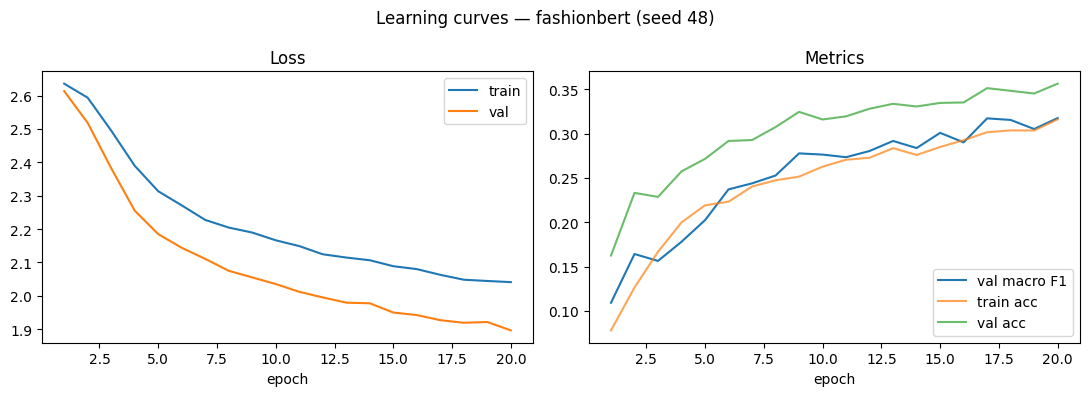

[fashionbert] Experiment 7/10 | data split seed = 53
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6337 acc 0.0832 | val loss 2.6103 acc 0.1493 macroF1 0.0947
Epoch 02 | train loss 2.5968 acc 0.1193 | val loss 2.5212 acc 0.2089 macroF1 0.1402
Epoch 03 | train loss 2.5057 acc 0.1626 | val loss 2.3751 acc 0.2386 macroF1 0.1726
Epoch 04 | train loss 2.4052 acc 0.1921 | val loss 2.2739 acc 0.2422 macroF1 0.1884
Epoch 05 | train loss 2.3287 acc 0.2158 | val loss 2.1783 acc 0.2608 macroF1 0.2105
Epoch 06 | train loss 2.2789 acc 0.2165 | val loss 2.1393 acc 0.2745 macroF1 0.2152
Epoch 07 | train loss 2.2480 acc 0.2369 | val loss 2.1008 acc 0.2962 macroF1 0.2449
Epoch 08 | train loss 2.2226 acc 0.2371 | val loss 2.0838 acc 0.2856 macroF1 0.2368
Epoch 09 | train loss 2.1897 acc 0.2545 | val loss 2.0524 acc 0.3088 macroF1 0.2586
Epoch 10 | train loss 2.1777 acc 0.2503 | val loss 2.0265 acc 0.3244 macroF1 0.2824
Epoch 11 | train loss 2.1547 acc 0.2644 | val loss 2.0090 acc 0.3199 macroF1 0.2691
Epoch 12 | train loss 2.1376 acc 0.2683 | val loss 1.9848 acc 0.3375 macroF1

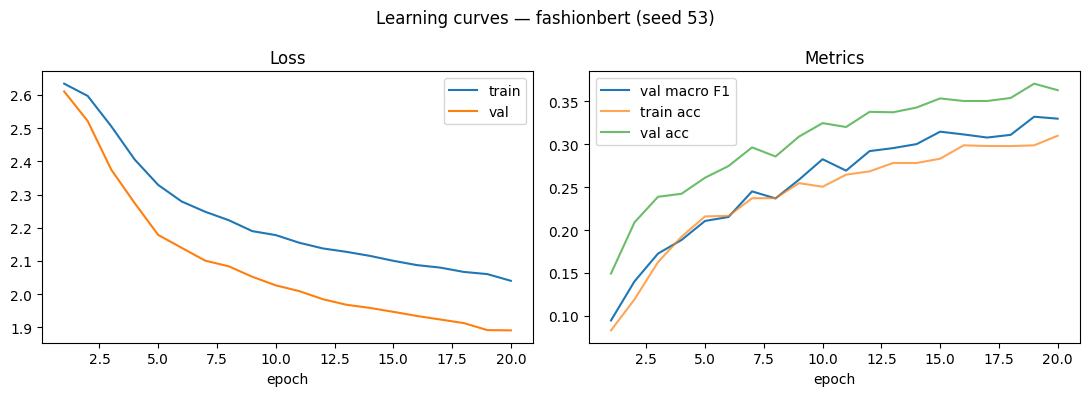

[fashionbert] Experiment 8/10 | data split seed = 58
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6341 acc 0.0837 | val loss 2.6119 acc 0.1504 macroF1 0.0974
Epoch 02 | train loss 2.6017 acc 0.1206 | val loss 2.5345 acc 0.2291 macroF1 0.1600
Epoch 03 | train loss 2.5102 acc 0.1696 | val loss 2.3863 acc 0.2270 macroF1 0.1573
Epoch 04 | train loss 2.4030 acc 0.1955 | val loss 2.2588 acc 0.2503 macroF1 0.1931
Epoch 05 | train loss 2.3293 acc 0.2111 | val loss 2.2027 acc 0.2674 macroF1 0.2071
Epoch 06 | train loss 2.2731 acc 0.2273 | val loss 2.1408 acc 0.2795 macroF1 0.2230
Epoch 07 | train loss 2.2449 acc 0.2378 | val loss 2.1144 acc 0.2866 macroF1 0.2298
Epoch 08 | train loss 2.2089 acc 0.2469 | val loss 2.0883 acc 0.2997 macroF1 0.2483
Epoch 09 | train loss 2.1780 acc 0.2554 | val loss 2.0548 acc 0.2987 macroF1 0.2547
Epoch 10 | train loss 2.1679 acc 0.2589 | val loss 2.0456 acc 0.2967 macroF1 0.2498
Epoch 11 | train loss 2.1465 acc 0.2649 | val loss 2.0373 acc 0.3098 macroF1 0.2642
Epoch 12 | train loss 2.1373 acc 0.2725 | val loss 2.0160 acc 0.3118 macroF1

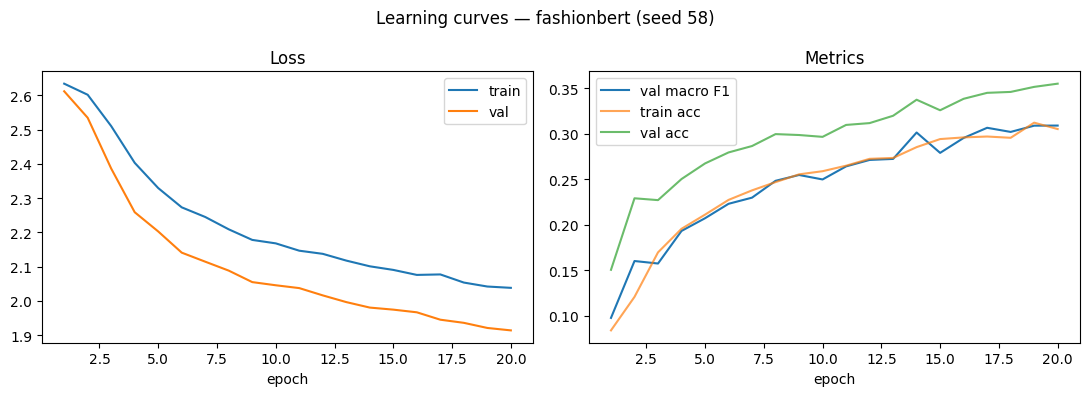

[fashionbert] Experiment 9/10 | data split seed = 72
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6348 acc 0.0826 | val loss 2.6145 acc 0.1352 macroF1 0.0880
Epoch 02 | train loss 2.5947 acc 0.1278 | val loss 2.5287 acc 0.2331 macroF1 0.1497
Epoch 03 | train loss 2.5062 acc 0.1680 | val loss 2.3781 acc 0.2487 macroF1 0.1744
Epoch 04 | train loss 2.4008 acc 0.2030 | val loss 2.2539 acc 0.2603 macroF1 0.1985
Epoch 05 | train loss 2.3240 acc 0.2123 | val loss 2.1855 acc 0.2654 macroF1 0.2098
Epoch 06 | train loss 2.2690 acc 0.2272 | val loss 2.1359 acc 0.2745 macroF1 0.2123
Epoch 07 | train loss 2.2375 acc 0.2348 | val loss 2.0953 acc 0.2836 macroF1 0.2298
Epoch 08 | train loss 2.2127 acc 0.2426 | val loss 2.0630 acc 0.2982 macroF1 0.2432
Epoch 09 | train loss 2.1894 acc 0.2513 | val loss 2.0475 acc 0.3047 macroF1 0.2496
Epoch 10 | train loss 2.1684 acc 0.2591 | val loss 2.0261 acc 0.3093 macroF1 0.2617
Epoch 11 | train loss 2.1532 acc 0.2703 | val loss 2.0077 acc 0.3093 macroF1 0.2597
Epoch 12 | train loss 2.1345 acc 0.2684 | val loss 2.0000 acc 0.3219 macroF1

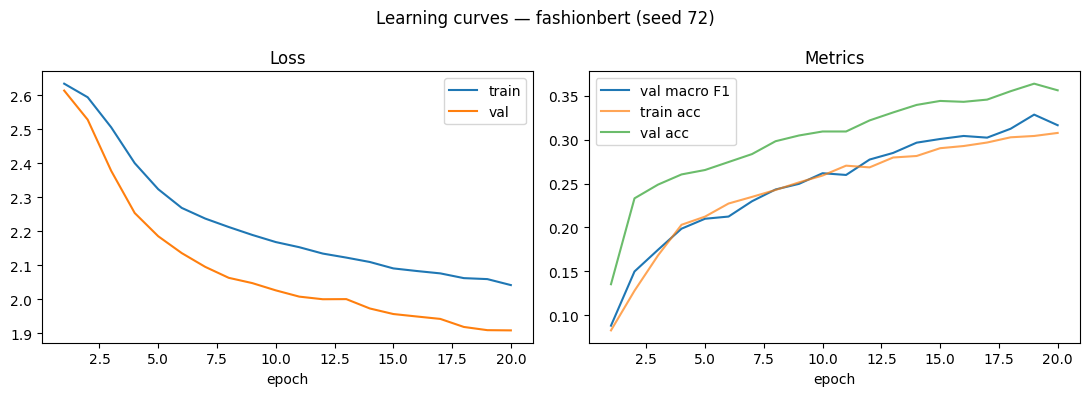

[fashionbert] Experiment 10/10 | data split seed = 102
  Split sizes: train=9248, val=1982, test=1982


c:\Users\Sandy\.conda\envs\DATA255\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 01 | train loss 2.6349 acc 0.0850 | val loss 2.6126 acc 0.1226 macroF1 0.0725
Epoch 02 | train loss 2.5983 acc 0.1272 | val loss 2.5304 acc 0.2240 macroF1 0.1505
Epoch 03 | train loss 2.5155 acc 0.1648 | val loss 2.3912 acc 0.2402 macroF1 0.1759
Epoch 04 | train loss 2.4084 acc 0.1926 | val loss 2.2672 acc 0.2634 macroF1 0.2053
Epoch 05 | train loss 2.3303 acc 0.2079 | val loss 2.1955 acc 0.2644 macroF1 0.1952
Epoch 06 | train loss 2.2717 acc 0.2239 | val loss 2.1455 acc 0.2709 macroF1 0.2191
Epoch 07 | train loss 2.2354 acc 0.2381 | val loss 2.1099 acc 0.2957 macroF1 0.2457
Epoch 08 | train loss 2.2086 acc 0.2442 | val loss 2.0830 acc 0.2967 macroF1 0.2471
Epoch 09 | train loss 2.1848 acc 0.2527 | val loss 2.0676 acc 0.3042 macroF1 0.2589
Epoch 10 | train loss 2.1607 acc 0.2648 | val loss 2.0396 acc 0.3113 macroF1 0.2632
Epoch 11 | train loss 2.1561 acc 0.2557 | val loss 2.0280 acc 0.3118 macroF1 0.2703
Epoch 12 | train loss 2.1327 acc 0.2690 | val loss 2.0149 acc 0.3123 macroF1

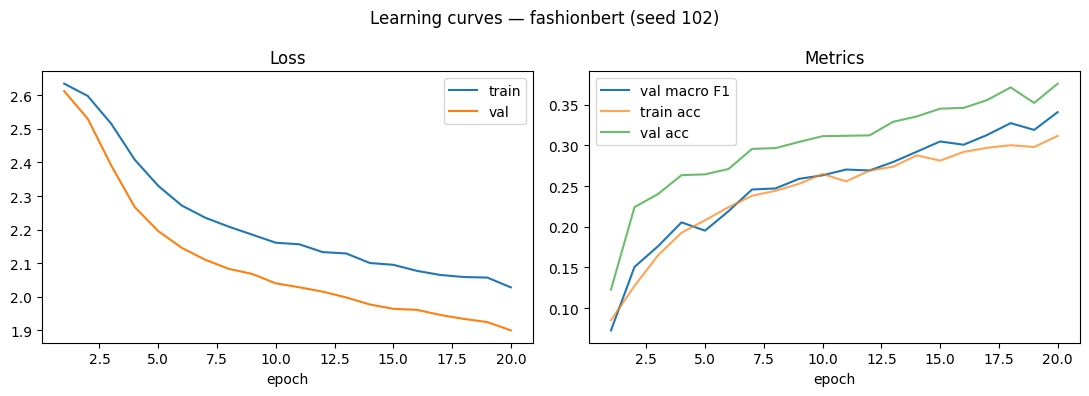


[fashionbert] Saved summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\text_only\fashionbert\all_seeds_summary.csv
[fashionbert] macro_f1 mean +/- std: 0.3322 +/- 0.0080


In [7]:
summary_bert = run_robustness_text(model_name="fashionbert", build_model_fn=build_model)

## 8. Aggregate comparison (10 seeds)

In [8]:
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]


def summarize_seeds(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    rows = []
    for col in metric_cols:
        if col not in df.columns:
            continue
        rows.append(
            {
                "model": model_name,
                "metric": col,
                "mean": float(df[col].mean()),
                "std": float(df[col].std()),
                "min": float(df[col].min()),
                "max": float(df[col].max()),
            }
        )
    return pd.DataFrame(rows)


summary_path = RESULTS_ROOT / "fashionbert" / "all_seeds_summary.csv"
print("Per-seed summary:", summary_path)

if summary_path.is_file():
    bert_df = pd.read_csv(summary_path)
    agg = summarize_seeds(bert_df, "fashionbert")
    print("\nTest metrics across seeds (mean +/- std):")
    print(agg.to_string(index=False))
else:
    print("Run section 7 first to generate all_seeds_summary.csv.")

Per-seed summary: C:\Users\Sandy\OneDrive\桌面\255\FusionStyle\results\text_only\fashionbert\all_seeds_summary.csv

Test metrics across seeds (mean +/- std):
      model          metric     mean      std      min      max
fashionbert        accuracy 0.369072 0.007363 0.355197 0.377397
fashionbert macro_precision 0.343154 0.014713 0.311798 0.367795
fashionbert    macro_recall 0.366319 0.007121 0.352205 0.375517
fashionbert        macro_f1 0.332197 0.007988 0.317648 0.342830
